# 04b — Churn cohort experiments (XGBoost + SHAP)

**Owner:** M2 (churn modeling)

Notebook 04 trained one XGBoost on the full panel and surfaced the SHAP top-10. This notebook **slices by purchase count** and trains a separate model per cohort, to see how the strategic feature ranking shifts when we focus on committed buyers.

Three cohorts, same Optuna-tuned hyperparameters from notebook 04, same temporal-split labels:

| Cohort | Filter | Expected behavior |
|---|---|---|
| **All** | every panel customer | timing features dominate (89% one-timer mass) |
| **2+ purchases** | `total_orders >= 2` | excludes one-timers; behavioral features start to rise |
| **6+ purchases** | `total_orders >= 6` | heavy buyers; expect discount / AOV / refund to dominate over timing |

Hypothesis: in the heavy-buyer cohort, every customer has well-established timing patterns, so timing features lose their grip and the model's churn signal comes from value/discount/refund behavior — the actually-marketing-actionable axes.

In [1]:
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, f1_score,
)
import xgboost as xgb
import shap
from lifetimes import BetaGeoFitter

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

ORDERS_PATH = "../data/features/orders_raw.csv"
MODELS_DIR = Path("../data/models"); MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR = Path("../docs/figures"); FIGS_DIR.mkdir(parents=True, exist_ok=True)

CHURN_WINDOW_DAYS = 299
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load Optuna-tuned hyperparameters from notebook 04 so all three cohorts use
# the same config — the comparison is then purely about the data slice.
with open(MODELS_DIR / "churn_xgboost_temporal_metrics.json") as f:
    nb04 = json.load(f)
BASE_PARAMS = nb04["optuna_best_params"]
print("Base hyperparams (from notebook 04):")
for k, v in BASE_PARAMS.items():
    print(f"  {k}: {v}")

Base hyperparams (from notebook 04):
  max_depth: 4
  learning_rate: 0.07382900309763066
  min_child_weight: 25
  subsample: 0.8860940017806965
  colsample_bytree: 0.8915333667340338
  reg_alpha: 0.02002086980132638
  reg_lambda: 0.01999514261897351
  gamma: 0.09738301233026535


## 1. Rebuild the feature table

Replays notebook 04's pipeline (orders → temporal split → customer aggregates → engineered features → BG/NBD scoring). Deterministic, ~30 sec. No fitting; BG/NBD params loaded from notebook 05's saved JSON.

In [2]:
orders = pd.read_csv(
    ORDERS_PATH,
    parse_dates=["ORDER_DATE"],
    dtype={"CUSTOMER_ID": "string", "ORDER_ID": "string", "FINANCIAL_STATUS": "category"},
)
orders.columns = [c.lower() for c in orders.columns]

max_date   = orders["order_date"].max()
split_date = max_date - pd.Timedelta(days=CHURN_WINDOW_DAYS)
valid = orders[~orders["financial_status"].isin(["refunded", "voided"])].copy()
pre   = valid[valid["order_date"] <= split_date]
post  = valid[valid["order_date"] >  split_date]
print(f"pre-split orders : {len(pre):,}")
print(f"split_date       : {split_date}")

pre-split orders : 483,083
split_date       : 2025-05-19 01:58:19


In [3]:
pre = pre.sort_values(["customer_id", "order_date"]).copy()
pre["gap_days"]        = pre.groupby("customer_id")["order_date"].diff().dt.days
pre["is_refund"]       = (pre["financial_status"] == "partially_refunded").astype("int8")
pre["discount_amount"] = (pre["product_amount"] - pre["amount_charged"]).clip(lower=0.0)
pre["had_discount"]    = (pre["discount_amount"] > 0.01).astype("int8")

agg = pre.groupby("customer_id").agg(
    total_orders            = ("order_id",        "count"),
    total_revenue           = ("amount_charged",  "sum"),
    avg_order_value         = ("amount_charged",  "mean"),
    first_order_date        = ("order_date",      "min"),
    last_order_date         = ("order_date",      "max"),
    avg_days_between_orders = ("gap_days",        "mean"),
    std_days_between_orders = ("gap_days",        "std"),
    refund_count            = ("is_refund",       "sum"),
    total_refund_amount     = ("amount_charged",  lambda s: s[pre.loc[s.index, "is_refund"] == 1].sum()),
    avg_discount_amount       = ("discount_amount", "mean"),
    pct_orders_with_discount  = ("had_discount",    "mean"),
).reset_index()

agg["t"]                     = (split_date - agg["first_order_date"]).dt.days.astype("int32")
agg["recency"]               = (agg["last_order_date"] - agg["first_order_date"]).dt.days.astype("int32")
agg["days_since_last_order"] = (split_date - agg["last_order_date"]).dt.days.astype("int32")
agg["frequency"]             = (agg["total_orders"] - 1).clip(lower=0).astype("int32")

repeat_idx = pre.groupby("customer_id").cumcount() > 0
monetary = pre[repeat_idx].groupby("customer_id")["amount_charged"].mean().rename("monetary_value")
agg = agg.merge(monetary, on="customer_id", how="left")
agg["monetary_value"] = agg["monetary_value"].fillna(0.0)
agg["avg_days_between_orders"] = agg["avg_days_between_orders"].fillna(0.0)
agg["std_days_between_orders"] = agg["std_days_between_orders"].fillna(0.0)
agg["refund_rate"] = agg["refund_count"] / agg["total_orders"]

for window in (30, 90, 180):
    cutoff = split_date - pd.Timedelta(days=window)
    recent = pre[pre["order_date"] > cutoff]
    counts = recent.groupby("customer_id").size().rename(f"orders_last_{window}d")
    revs   = recent.groupby("customer_id")["amount_charged"].sum().rename(f"revenue_last_{window}d")
    agg = agg.merge(counts, on="customer_id", how="left").merge(revs, on="customer_id", how="left")
    agg[f"orders_last_{window}d"]  = agg[f"orders_last_{window}d"].fillna(0).astype("int32")
    agg[f"revenue_last_{window}d"] = agg[f"revenue_last_{window}d"].fillna(0.0)

agg = agg[agg["t"] >= 0].reset_index(drop=True)

active_after = set(post["customer_id"].unique())
agg["is_churned"] = (~agg["customer_id"].isin(active_after)).astype("int8")
print(f"customers: {len(agg):,}   churn rate: {agg['is_churned'].mean():.4f}")

customers: 395,612   churn rate: 0.9417


In [4]:
df = agg.copy()

df["is_one_time"]              = (df["frequency"] == 0).astype("int8")
df["recency_per_gap"]          = df["recency"] / (df["avg_days_between_orders"] + 1.0)
df["gap_cv"]                   = df["std_days_between_orders"] / (df["avg_days_between_orders"] + 1.0)
df["value_density"]            = df["total_revenue"] / (df["recency"] + 1.0)
df["purchases_per_day_active"] = df["total_orders"] / (df["recency"] + 1.0)
df["dsl_per_t"]                = df["days_since_last_order"] / (df["t"] + 1.0)
df["dsl_per_gap"]              = df["days_since_last_order"] / (df["avg_days_between_orders"] + 1.0)
df["orders_acceleration"]      = df["orders_last_30d"]  / (df["orders_last_180d"]  + 1.0)
df["revenue_acceleration"]     = df["revenue_last_30d"] / (df["revenue_last_180d"] + 1.0)
df["share_recent_orders"]      = df["orders_last_90d"]  / (df["total_orders"]      + 0.0)
df["share_recent_revenue"]     = df["revenue_last_90d"] / (df["total_revenue"]     + 1.0)

for col in ["total_revenue", "avg_order_value", "monetary_value", "total_refund_amount",
            "value_density", "revenue_last_30d", "revenue_last_90d", "revenue_last_180d",
            "avg_discount_amount"]:
    df[f"log_{col}"] = np.log1p(df[col].clip(lower=0))

# BG/NBD scoring (params from notebook 05; no refit)
with open(MODELS_DIR / "bgnbd_temporal_params.json") as f:
    bgnbd_params = json.load(f)
_bgf = BetaGeoFitter(penalizer_coef=0.01)
_bgf.params_ = pd.Series(bgnbd_params)

f_in = df["frequency"].clip(lower=0).astype("float64")
T_in = df["t"].clip(lower=0).astype("float64")
r_in = np.minimum(df["recency"].clip(lower=0).astype("float64"), T_in)
df["bgnbd_p_alive"]          = np.asarray(_bgf.conditional_probability_alive(f_in, r_in, T_in))
df["bgnbd_e_purchases_299d"] = np.asarray(_bgf.conditional_expected_number_of_purchases_up_to_time(
    float(CHURN_WINDOW_DAYS), f_in, r_in, T_in
))

FEATURE_COLS = [
    "t", "recency", "days_since_last_order",
    "frequency", "total_orders", "refund_count", "refund_rate",
    "monetary_value", "avg_order_value", "total_revenue", "total_refund_amount",
    "log_monetary_value", "log_avg_order_value", "log_total_revenue", "log_total_refund_amount",
    "avg_days_between_orders", "std_days_between_orders",
    "orders_last_30d", "orders_last_90d", "orders_last_180d",
    "revenue_last_30d", "revenue_last_90d", "revenue_last_180d",
    "log_revenue_last_30d", "log_revenue_last_90d", "log_revenue_last_180d",
    "avg_discount_amount", "log_avg_discount_amount", "pct_orders_with_discount",
    "is_one_time", "recency_per_gap", "gap_cv",
    "value_density", "log_value_density", "purchases_per_day_active",
    "dsl_per_t", "dsl_per_gap",
    "orders_acceleration", "revenue_acceleration",
    "share_recent_orders", "share_recent_revenue",
    "bgnbd_p_alive", "bgnbd_e_purchases_299d",
]
print(f"df shape: {df.shape}    feature count: {len(FEATURE_COLS)}")

df shape: (395612, 47)    feature count: 43


## 2. Define cohorts

In [5]:
COHORTS = [
    ("all",                  df,                              "All customers"),
    ("total_orders_ge_2",    df[df["total_orders"] >= 2],     "total_orders >= 2  (no one-timers)"),
    ("total_orders_ge_6",    df[df["total_orders"] >= 6],     "total_orders >= 6  (heavy buyers)"),
]

for slug, sub, label in COHORTS:
    n = len(sub)
    churn = float(sub["is_churned"].mean())
    print(f"{label:<45}  n={n:>7,}   churn_rate={churn:.4f}")

All customers                                  n=395,612   churn_rate=0.9417
total_orders >= 2  (no one-timers)             n= 47,251   churn_rate=0.8711
total_orders >= 6  (heavy buyers)              n=  1,340   churn_rate=0.5366


## 3. Train + SHAP per cohort

Same XGBoost config across cohorts (notebook 04's Optuna best) — only `scale_pos_weight` varies because it's defined by each cohort's class balance. Stratified 80/20 split, early stopping on test AUROC.

In [6]:
def train_eval_cohort(slug, sub, label):
    X = sub[FEATURE_COLS].astype("float32")
    y = sub["is_churned"].astype("int8")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
    )
    spw = float((y_tr == 0).sum() / max(int((y_tr == 1).sum()), 1))

    params = {
        **BASE_PARAMS,
        "n_estimators": 3000,
        "scale_pos_weight": spw,
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "early_stopping_rounds": 60,
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=0)

    probs = model.predict_proba(X_te)[:, 1]
    auroc = float(roc_auc_score(y_te, probs))
    auprc = float(average_precision_score(y_te, probs))

    thr = np.linspace(0.05, 0.95, 91)
    f1s = np.array([f1_score(y_te, (probs >= t).astype(int)) for t in thr])
    bi = int(np.argmax(f1s))
    best_t = float(thr[bi]); best_f1 = float(f1s[bi])

    shap_n = min(5000, len(X_te))
    rng = np.random.RandomState(RANDOM_STATE)
    shap_idx = rng.choice(len(X_te), size=shap_n, replace=False)
    X_shap = X_te.iloc[shap_idx]
    probs_shap = probs[shap_idx]
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_shap)
    mean_abs = np.abs(shap_vals).mean(axis=0)
    shap_top10 = pd.Series(mean_abs, index=FEATURE_COLS).sort_values(ascending=False).head(10)

    print(f"{label}")
    print(f"  n_train={len(X_tr):,}  n_test={len(X_te):,}  spw={spw:.4f}")
    print(f"  test AUROC = {auroc:.4f}    AUPRC = {auprc:.4f}")
    print(f"  best_iteration = {model.best_iteration}    best_F1_threshold = {best_t:.2f}  (F1={best_f1:.4f})")
    print("  SHAP top 10 (mean|SHAP|):")
    for f, v in shap_top10.items():
        print(f"    {f:<30s}  {v:.4f}")
    print()

    return dict(
        slug=slug, label=label,
        n_train=int(len(X_tr)), n_test=int(len(X_te)),
        train_churn_rate=float(y_tr.mean()),
        test_auroc=auroc, test_auprc=auprc,
        best_iteration=int(model.best_iteration),
        best_f1_threshold=best_t, best_f1=best_f1,
        scale_pos_weight=spw,
        shap_top10=shap_top10.round(4).to_dict(),
        model=model, X_te=X_te, y_te=y_te, probs=probs,
        shap_vals=shap_vals, X_shap=X_shap, explainer=explainer, probs_shap=probs_shap,
    )

In [7]:
#%pip install "shap==0.51.0"

In [8]:
results = []
for slug, sub, label in COHORTS:
    r = train_eval_cohort(slug, sub, label)
    results.append(r)

All customers
  n_train=316,489  n_test=79,123  spw=0.0619
  test AUROC = 0.6862    AUPRC = 0.9688
  best_iteration = 111    best_F1_threshold = 0.08  (F1=0.9704)
  SHAP top 10 (mean|SHAP|):
    bgnbd_e_purchases_299d          0.2701
    dsl_per_gap                     0.1046
    avg_discount_amount             0.1001
    dsl_per_t                       0.0846
    avg_order_value                 0.0677
    total_revenue                   0.0498
    days_since_last_order           0.0492
    t                               0.0364
    recency_per_gap                 0.0296
    value_density                   0.0151

total_orders >= 2  (no one-timers)
  n_train=37,800  n_test=9,451  spw=0.1480
  test AUROC = 0.7206    AUPRC = 0.9399
  best_iteration = 137    best_F1_threshold = 0.16  (F1=0.9358)
  SHAP top 10 (mean|SHAP|):
    bgnbd_p_alive                   0.1786
    dsl_per_t                       0.1680
    bgnbd_e_purchases_299d          0.1606
    dsl_per_gap                     0.0

## 4. Side-by-side comparison

In [9]:
comp = pd.DataFrame([
    {
        "cohort": r["label"],
        "n_train": r["n_train"],
        "n_test": r["n_test"],
        "train_churn": round(r["train_churn_rate"], 4),
        "test_AUROC": round(r["test_auroc"], 4),
        "test_AUPRC": round(r["test_auprc"], 4),
        "best_F1": round(r["best_f1"], 4),
        "best_F1_thr": round(r["best_f1_threshold"], 2),
    } for r in results
])
print(comp.to_string(index=False))

                            cohort  n_train  n_test  train_churn  test_AUROC  test_AUPRC  best_F1  best_F1_thr
                     All customers   316489   79123       0.9417      0.6862      0.9688   0.9704         0.08
total_orders >= 2  (no one-timers)    37800    9451       0.8711      0.7206      0.9399   0.9358         0.16
 total_orders >= 6  (heavy buyers)     1072     268       0.5364      0.8232      0.8657   0.7754         0.44


In [10]:
# Top SHAP features per cohort, side-by-side (ranks)
rank_df = pd.DataFrame()
for r in results:
    ser = pd.Series(r["shap_top10"]).sort_values(ascending=False)
    ranks = pd.Series({f: i + 1 for i, f in enumerate(ser.index)}, name=r["label"])
    rank_df = pd.concat([rank_df, ranks], axis=1)

rank_df = rank_df.fillna("-").astype(object)
print("SHAP top-10 feature RANK per cohort (lower = more important; '-' = not in cohort's top 10)")
print("=" * 110)
print(rank_df.to_string())

# Also show the raw mean|SHAP| values side-by-side
val_df = pd.DataFrame()
for r in results:
    val_df = pd.concat([val_df, pd.Series(r["shap_top10"], name=r["label"])], axis=1)
val_df = val_df.fillna(0)
print()
print("SHAP mean(|SHAP|) values side-by-side (0 means not in top 10):")
print("=" * 110)
print(val_df.round(4).to_string())

SHAP top-10 feature RANK per cohort (lower = more important; '-' = not in cohort's top 10)
                        All customers total_orders >= 2  (no one-timers) total_orders >= 6  (heavy buyers)
bgnbd_e_purchases_299d            1.0                                3.0                                 -
dsl_per_gap                       2.0                                4.0                               4.0
avg_discount_amount               3.0                                6.0                               5.0
dsl_per_t                         4.0                                2.0                                 -
avg_order_value                   5.0                                8.0                                 -
total_revenue                     6.0                               10.0                              10.0
days_since_last_order             7.0                                5.0                               1.0
t                                 8.0                

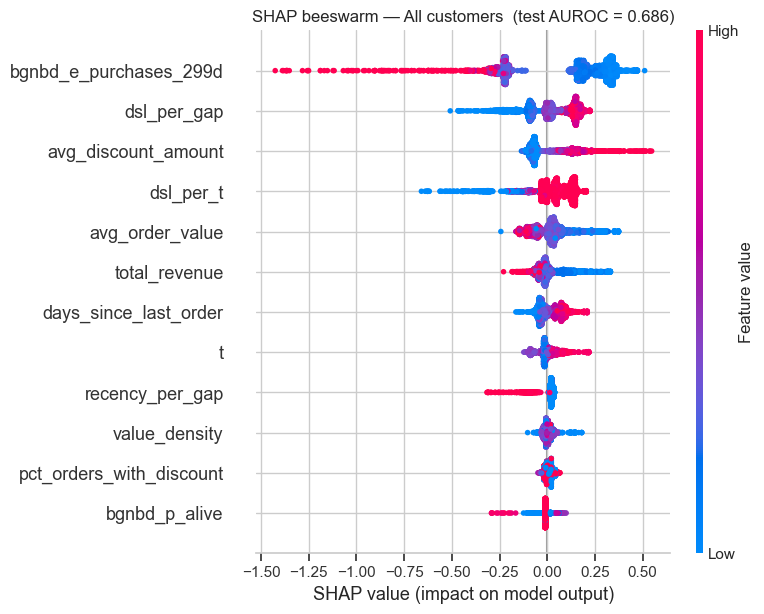

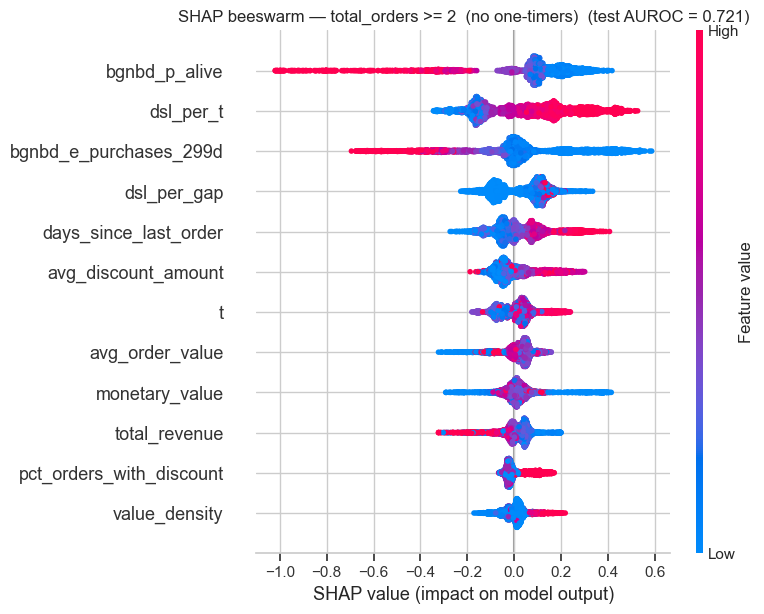

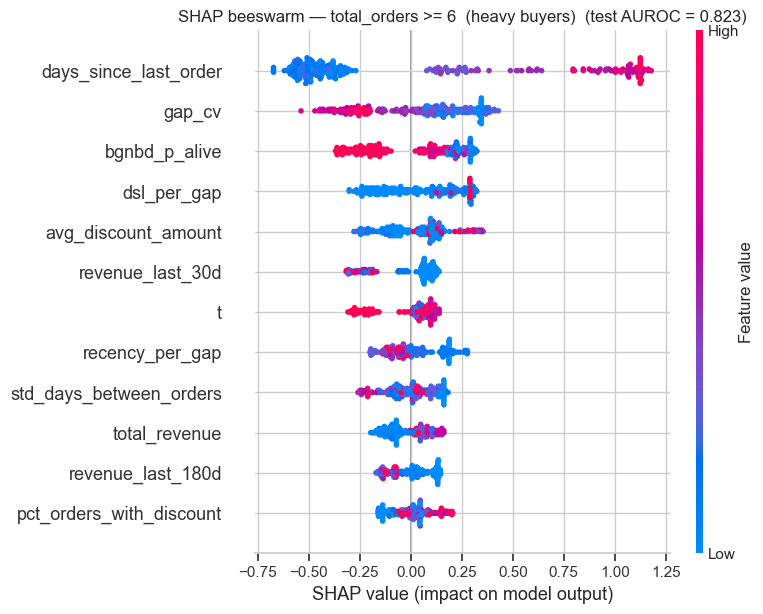

In [11]:
for r in results:
    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        r["shap_vals"], r["X_shap"],
        feature_names=FEATURE_COLS,
        show=False, max_display=12,
    )
    plt.title(f"SHAP beeswarm — {r['label']}  (test AUROC = {r['test_auroc']:.3f})")
    plt.tight_layout()
    plt.savefig(FIGS_DIR / f"churn_xgb_cohort_shap_{r['slug']}.png",
                dpi=120, bbox_inches="tight")
    plt.show()

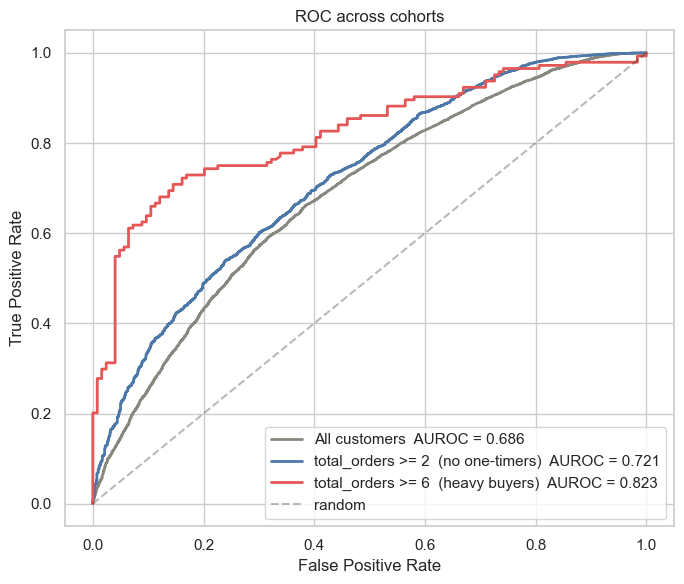

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
for r, color in zip(results, ["#888780", "#4C78A8", "#E45756"]):
    fpr, tpr, _ = roc_curve(r["y_te"], r["probs"])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{r['label']}  AUROC = {r['test_auroc']:.3f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC across cohorts")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGS_DIR / "churn_xgb_cohort_roc_overlay.png", dpi=120)
plt.show()

## 5. Save metrics

In [13]:
out = {
    "base_hyperparams": BASE_PARAMS,
    "churn_window_days": CHURN_WINDOW_DAYS,
    "split_date": split_date.isoformat(),
    "experiments": [
        {k: v for k, v in r.items() if k in {
            "slug", "label", "n_train", "n_test", "train_churn_rate",
            "test_auroc", "test_auprc", "best_iteration",
            "best_f1_threshold", "best_f1", "scale_pos_weight", "shap_top10",
        }} for r in results
    ],
    "trained": datetime.now().isoformat(timespec="seconds"),
}
out_path = MODELS_DIR / "churn_xgboost_cohort_experiments.json"
with open(out_path, "w") as f:
    json.dump(out, f, indent=2)
print(f"saved {out_path}")
print()
print(json.dumps(out, indent=2))

saved ..\data\models\churn_xgboost_cohort_experiments.json

{
  "base_hyperparams": {
    "max_depth": 4,
    "learning_rate": 0.07382900309763066,
    "min_child_weight": 25,
    "subsample": 0.8860940017806965,
    "colsample_bytree": 0.8915333667340338,
    "reg_alpha": 0.02002086980132638,
    "reg_lambda": 0.01999514261897351,
    "gamma": 0.09738301233026535
  },
  "churn_window_days": 299,
  "split_date": "2025-05-19T01:58:19",
  "experiments": [
    {
      "slug": "all",
      "label": "All customers",
      "n_train": 316489,
      "n_test": 79123,
      "train_churn_rate": 0.9416946560543968,
      "test_auroc": 0.6862134207089177,
      "test_auprc": 0.9687784838306174,
      "best_iteration": 111,
      "best_f1_threshold": 0.08,
      "best_f1": 0.9704288629946727,
      "scale_pos_weight": 0.0619153390865533,
      "shap_top10": {
        "bgnbd_e_purchases_299d": 0.2700999975204468,
        "dsl_per_gap": 0.10459999740123749,
        "avg_discount_amount": 0.10010000318

## Acceptance criteria
- [x] Feature pipeline replayed deterministically (orders → agg → fe → BG/NBD scoring)
- [x] Same hyperparameters across cohorts (from notebook 04 Optuna sweep)
- [x] Three cohorts: all, `total_orders >= 2`, `total_orders >= 6`
- [x] AUROC + AUPRC + best-F1 per cohort
- [x] SHAP top-10 per cohort, displayed side-by-side as ranks AND values
- [x] SHAP beeswarm saved per cohort
- [x] ROC overlay across cohorts
- [x] Cohort metrics saved to `data/models/churn_xgboost_cohort_experiments.json`